In [ ]:
#Hamza ALsihati
#2230006810
#8MA1
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgFile = 'Images/kid1.jpg'

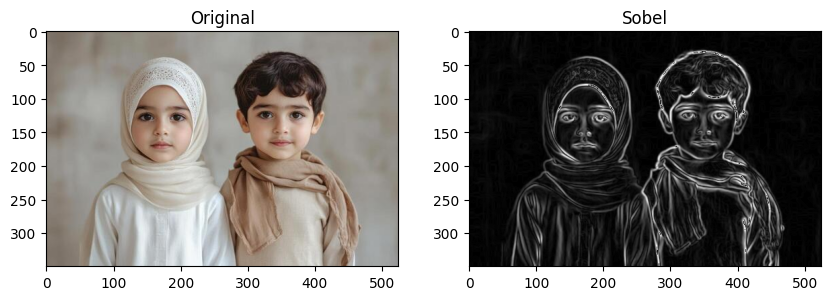

In [4]:
img = cv2.imread(imgFile)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)
sobel_final = np.uint8(np.absolute(sobel_combined))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(sobel_final, cmap='gray')
plt.title('Sobel')
plt.show()

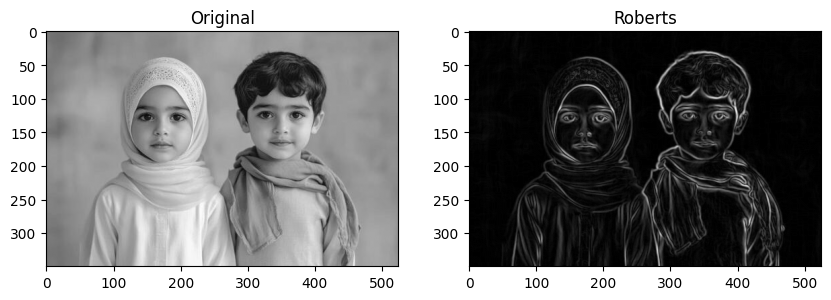

In [5]:
image = cv2.imread(imgFile, 0)
blurred = cv2.GaussianBlur(image, (5, 5), 0)

kernel_x = np.array([[1, 0], [0, -1]], dtype=np.float64)
kernel_y = np.array([[0, 1], [-1, 0]], dtype=np.float64)
roberts_x = cv2.filter2D(blurred, cv2.CV_64F, kernel_x)
roberts_y = cv2.filter2D(blurred, cv2.CV_64F, kernel_y)
roberts_combined = cv2.magnitude(roberts_x, roberts_y)
roberts_final = np.uint8(np.absolute(roberts_combined))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(roberts_final, cmap='gray')
plt.title('Roberts')
plt.show()

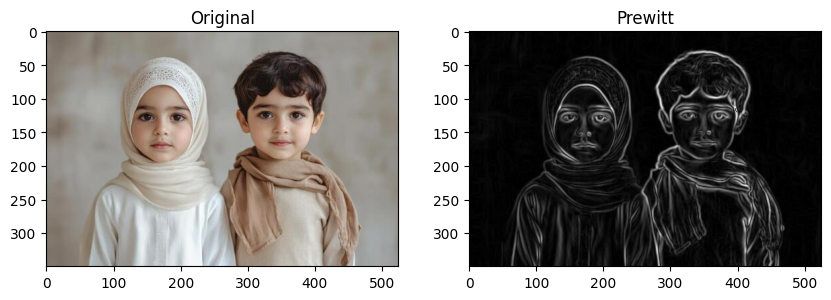

In [6]:
img = cv2.imread(imgFile)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float64)
kernel_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float64)
prewitt_x = cv2.filter2D(blurred, cv2.CV_64F, kernel_x)
prewitt_y = cv2.filter2D(blurred, cv2.CV_64F, kernel_y)
prewitt_combined = cv2.magnitude(prewitt_x, prewitt_y)
prewitt_final = np.uint8(np.absolute(prewitt_combined))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(prewitt_final, cmap='gray')
plt.title('Prewitt')
plt.show()

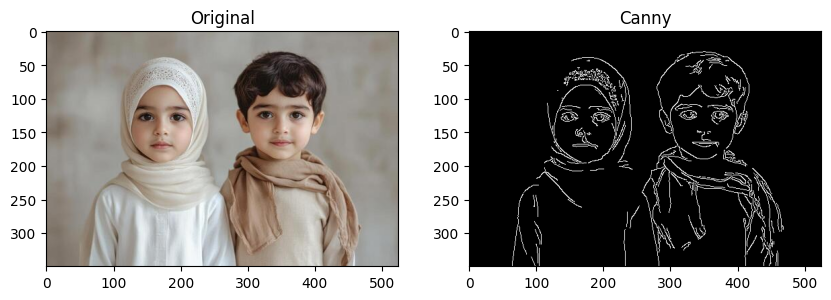

In [7]:
img = cv2.imread(imgFile)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny_edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(canny_edges, cmap='gray')
plt.title('Canny')
plt.show()

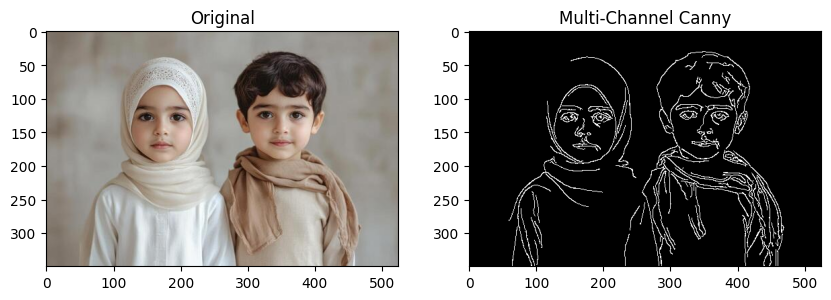

In [8]:
img = cv2.imread(imgFile)
channels = cv2.split(img)
edge_maps = []

for channel in channels:
    blurred = cv2.GaussianBlur(channel, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    edge_maps.append(edges)

combined_edges = cv2.bitwise_or(edge_maps[0], edge_maps[1])
combined_edges = cv2.bitwise_or(combined_edges, edge_maps[2])

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(combined_edges, cmap='gray')
plt.title('Multi-Channel Canny')
plt.show()

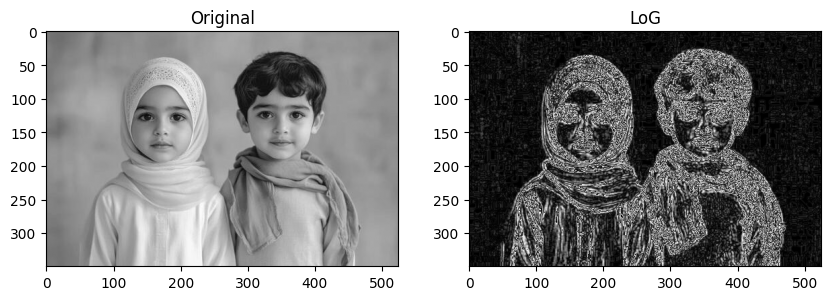

In [9]:
img = cv2.imread(imgFile, cv2.IMREAD_GRAYSCALE)
blurred = cv2.GaussianBlur(img, (5, 5), 0)
laplacian = cv2.Laplacian(blurred, cv2.CV_64F, ksize=5)
log_final = np.uint8(np.absolute(laplacian))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(log_final, cmap='gray')
plt.title('LoG')
plt.show()

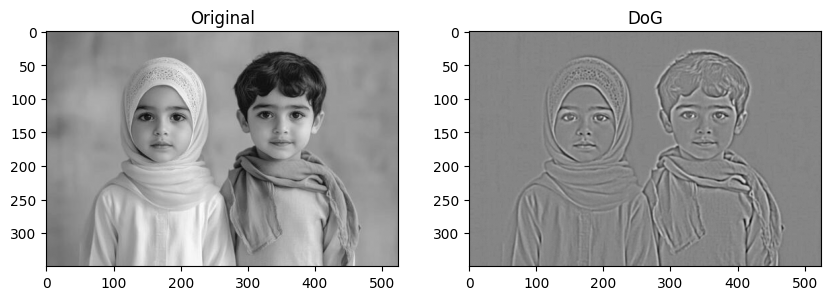

In [10]:
img = cv2.imread(imgFile, cv2.IMREAD_GRAYSCALE)
blur_narrow = cv2.GaussianBlur(img, (0, 0), sigmaX=1.0)
blur_wide = cv2.GaussianBlur(img, (0, 0), sigmaX=2.0)
dog = blur_narrow.astype(np.float32) - blur_wide.astype(np.float32)
dog_normalized = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(dog_normalized, cmap='gray')
plt.title('DoG')
plt.show()

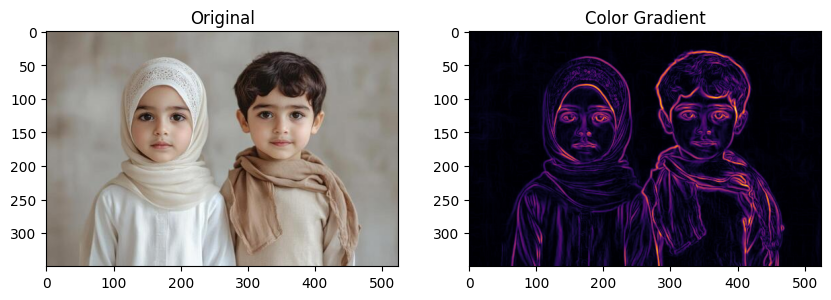

In [11]:
image = cv2.imread(imgFile)
b, g, r = cv2.split(image)

def get_channel_gradient(channel):
    blurred = cv2.GaussianBlur(channel, (3, 3), 0)
    gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    return cv2.magnitude(gx, gy)

grad_b = get_channel_gradient(b)
grad_g = get_channel_gradient(g)
grad_r = get_channel_gradient(r)
combined_gradient = np.sqrt(grad_b**2 + grad_g**2 + grad_r**2)
color_edges = cv2.normalize(combined_gradient, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(color_edges, cmap='inferno')
plt.title('Color Gradient')
plt.show()